In [1]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
import matplotlib.patches as mpatches
import metpy.calc as mpcalc
import matplotlib.colors as mcolors
%run ../functions/Transfer_longitude.ipynb
%run ../functions/Yearly_mean.ipynb
%run ../functions/Seasonal_means.ipynb
%run ../functions/Weighted_monthly_mean.ipynb
%run ../functions/Colormap_lib.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /knight/anaconda_aug22/envs/aug22_env/share/proj failed


## Read the data

In [2]:
def read_the_data(diri):
    diri=diri
    filename='partial_x_sst_06.nc'
    fi=xr.open_dataset(diri+filename)
    var_ref6=fi.var_ref
    filename='partial_x_sst_07.nc'
    fi=xr.open_dataset(diri+filename)
    var_ref7=fi.var_ref
    filename='partial_x_sst_08.nc'
    fi=xr.open_dataset(diri+filename)
    var_ref8=fi.var_ref
    var_JJA=(var_ref6+var_ref7+var_ref8)/3

    filename='partial_x_sst_09.nc'
    fi=xr.open_dataset(diri+filename)
    var_ref9=fi.var_ref
    filename='partial_x_sst_10.nc'
    fi=xr.open_dataset(diri+filename)
    var_ref10=fi.var_ref
    filename='partial_x_sst_11.nc'
    fi=xr.open_dataset(diri+filename)
    var_ref11=fi.var_ref
    var_SON=(var_ref9+var_ref10+var_ref11)/3
    var=(var_JJA+var_SON)/2 # for 
    return var

# diri='/zhoulab_rit/lzhuo/data/GFDL_patch/Sahara/A1p5_30yr/point/pvalue90/'
diri='/zhoulab_rit/lzhuo/data/GFDL_patch/Sahara/A1p5_30yr/point/pvalue95/'
var_1p5_30=read_the_data(diri)
diri='/zhoulab_rit/lzhuo/data/GFDL_patch/Sahara/A4p0/point/pvalue95/'
var_4p5=read_the_data(diri)
# diri=diri='/zhoulab_rit/lzhuo/data/GFDL_patch/Sahara/A1p5_10yr/point/pvalue90/'
diri=diri='/zhoulab_rit/lzhuo/data/GFDL_patch/Sahara/A1p5_10yr/point/pvalue95/'
var_1p5_10=read_the_data(diri)

## Calculate the average
var_mean=(var_1p5_30+var_4p5+var_1p5_10)/3

## Calculate the area for each ocean grid box
Area=var_1p5_30.copy()
# First, define all values to 1
Area[:,:]=1

re=6371008.7714 #m
dlon=2.5 #grid size in longitude (degree)
dlat=2   #grid size in latitude (degree)
d_phi=np.deg2rad(dlat) # grid size in latitude (radians)
d_theta=np.deg2rad(dlon) #grid size in longitude (radians)
Area=Area*re**2*np.cos(np.deg2rad(Area.lat))*d_phi*d_theta # The unit is m**2; Is this right? --Yes, it is but I do not like this coding style

sen2sst_1p5_30=var_1p5_30*1e14/Area
sen2sst_4p5   =var_4p5*1e14/Area
sen2sst_1p5_10=var_1p5_10*1e14/Area
sen2sst_mean=var_mean*1e14/Area

Text(0.5, 1.0, 'Mean')

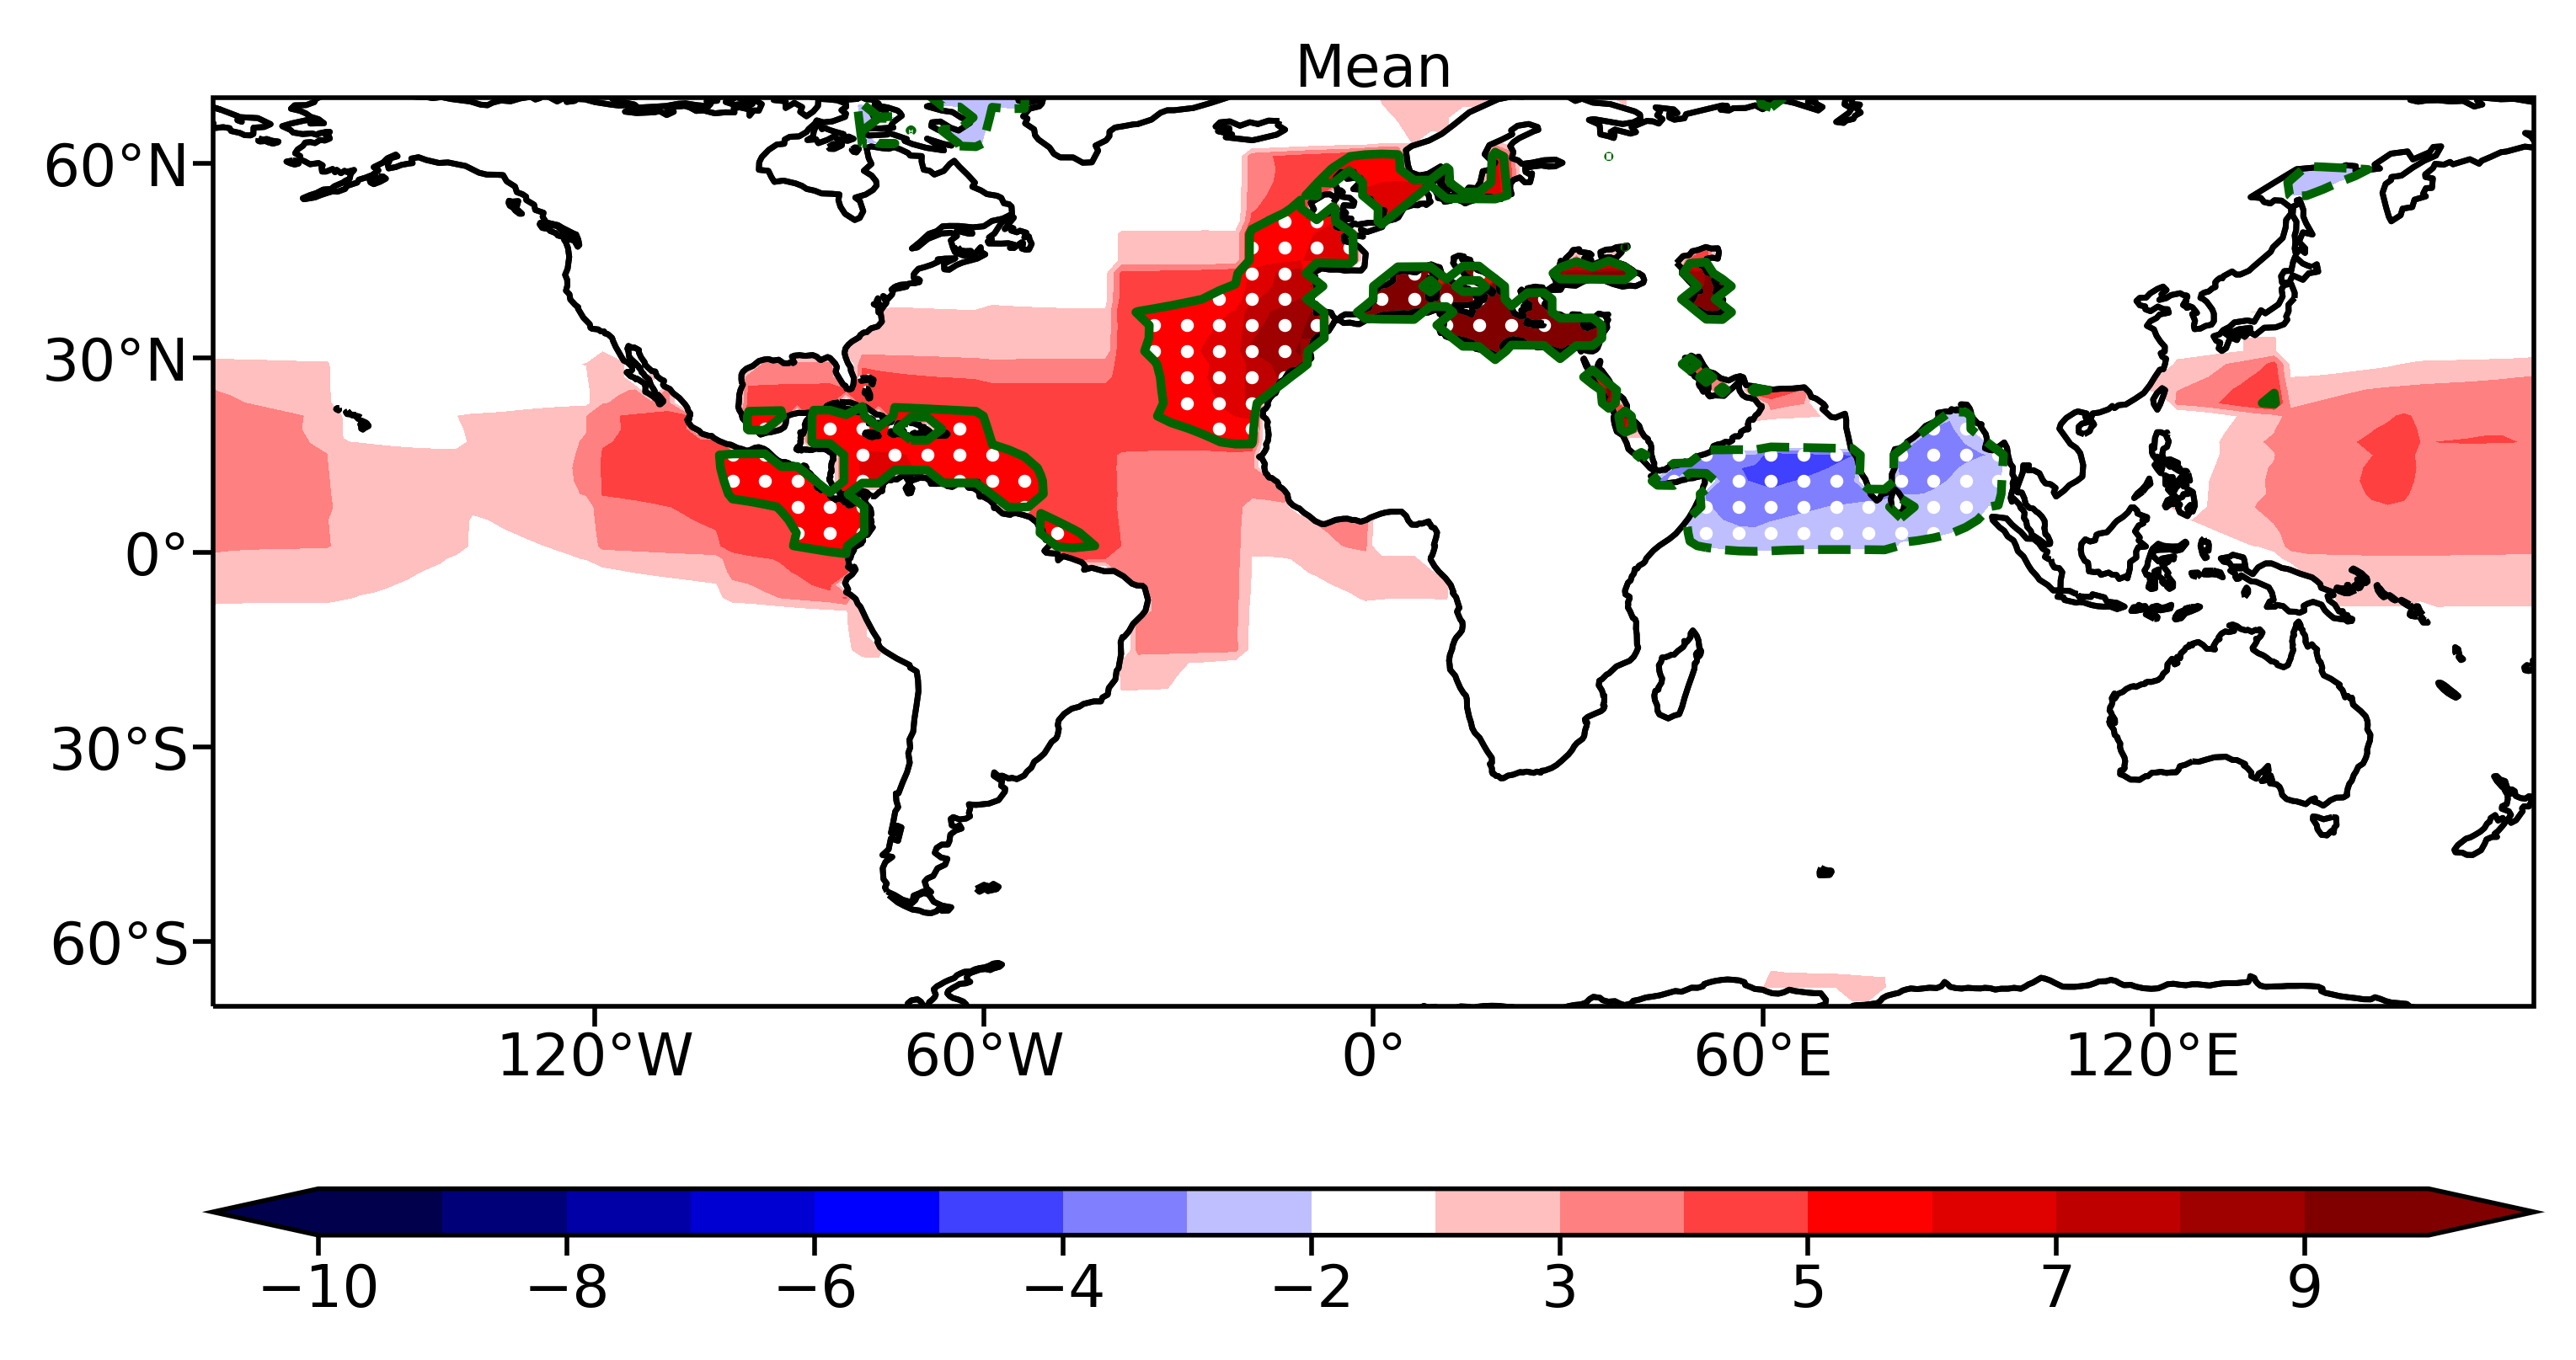

In [24]:
def plot_background_line(ax,var,intervals,levels):
    lonW = -178.8
    lonE = 178.8
    latS = -70
    latN = 70.0
    fontsize=10
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '110m'
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.set_xticks([-120,-60,0,60,120], crs=ccrs.PlateCarree())
    ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
    lats=var.lat
    lons=var.lon
    
#     bounds = np.arange(-10, 11, 1)
    bounds = np.array([-10,-9,-8,-7,-6,-5,-4,-3,-2,2,3,4,5,6,7,8,9,10])
    N = len(bounds) - 1

#     base = plt.cm.get_cmap("bwr", N)
#     colors = base(np.arange(N))
#     # 找到 [-2,2] 对应的 bin
#     for v in [-2, -1, 0, 1]:
#         i = np.where(bounds[:-1] == v)[0][0]
#         colors[i] = [1, 1, 1, 1]   # 白色

    # 1) 先做一个离散版 bwr（每个 bin 一个颜色）
    base = plt.cm.get_cmap("seismic", N)
    colors = base(np.arange(N))

    # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
    #    bin i 对应 [bounds[i], bounds[i+1]]
    i1 = np.where(bounds[:-1] == -2)[0][0]  # [-1,0]
#     i2 = np.where(bounds[:-1] ==  0)[0][0]  # [0,1]
    colors[i1] = [1, 1, 1, 1]

    # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
#     #    bin i 对应 [bounds[i], bounds[i+1]]
#     i1 = np.where(bounds[:-1] == -2)[0][0]  # [-1,0]
#     i2 = np.where(bounds[:-1] ==  2)[0][0]  # [0,1]
#     colors[i1] = [1, 1, 1, 1]
#     colors[i2] = [1, 1, 1, 1]
    
#     for v in [-2, -1, 0, 1]:
#         i = np.where(bounds[:-1] == v)[0][0]
#         colors[i] = [1, 1, 1, 1]   # 白色

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    CF = ax.contourf(lons,lats,var,bounds,transform=proj_data,norm=norm,
                 cmap=cmap,extend='both') #cmap=plt.get_cmap('seismic')
#     levels=np.array([5])
    CF_line = ax.contour(lons,lats,var,levels,transform=proj_data,colors='darkgreen',linewidths=1.5)
#     ax.clabel(CF_line, inline=True, fontsize=10, fmt="%.1f")
    ax.add_feature(cfeature.COASTLINE.with_scale(res),color='black',linewidth=1)
    ax.add_feature(cfeature.LAND, color='white',zorder=1)
#     ax.add_patch(                                            # Med; lat:30-40; lon:0-40
#             mpatches.Rectangle(xy=[0, 30],
#                                width=40,
#                                height=10,
#                                facecolor='None',
#                                edgecolor='blue',
#                                lw=1,
#                                transform=ccrs.PlateCarree()))
#     ax.add_patch(                                            # East Atlantic; lat:25-45; lon:-25-(-5)
#             mpatches.Rectangle(xy=[-25, 25],
#                                width=20,
#                                height=20,
#                                facecolor='None',
#                                edgecolor='blue',
#                                lw=1,
#                                transform=ccrs.PlateCarree()))
#     ax.add_patch(                                            # Caribbean sea; lat:10-25; lon:-90-(-60)
#             mpatches.Rectangle(xy=[-90, 10],
#                                width=30,
#                                height=15,
#                                facecolor='None',
#                                edgecolor='blue',
#                                lw=1,
#                                transform=ccrs.PlateCarree()))
    var_temp=var.sel(lat=slice(-90,52),lon=slice(-180,30))
    nx, ny = np.meshgrid(var_temp[::2,::2].lon, var_temp[::2,::2].lat)
    area = np.where(var_temp[::2,::2] > 5)
    sig1 = ax.scatter(nx[area], ny[area],  s = 1.5, c = 'white', transform = ccrs.PlateCarree())
    
    var_temp=var.sel(lat=slice(-90,30))
    nx, ny = np.meshgrid(var_temp[::2,::2].lon, var_temp[::2,::2].lat)
    area = np.where(var_temp[::2,::2] < -2)
    sig1 = ax.scatter(nx[area], ny[area],  s = 1.5, c = 'white', transform = ccrs.PlateCarree())
        
    ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

fig = plt.figure(figsize=(6, 5),dpi=500,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -10
maxVal = 10+1
cint = 1
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

levels=np.array([-2,5])

ax1,CF =plot_background_line(ax,sen2sst_mean,intervals,levels)
fontsize=12
pad=0.5
ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title('Mean',fontsize=10,pad=1)

Text(0.5, 1.0, 'Mean')

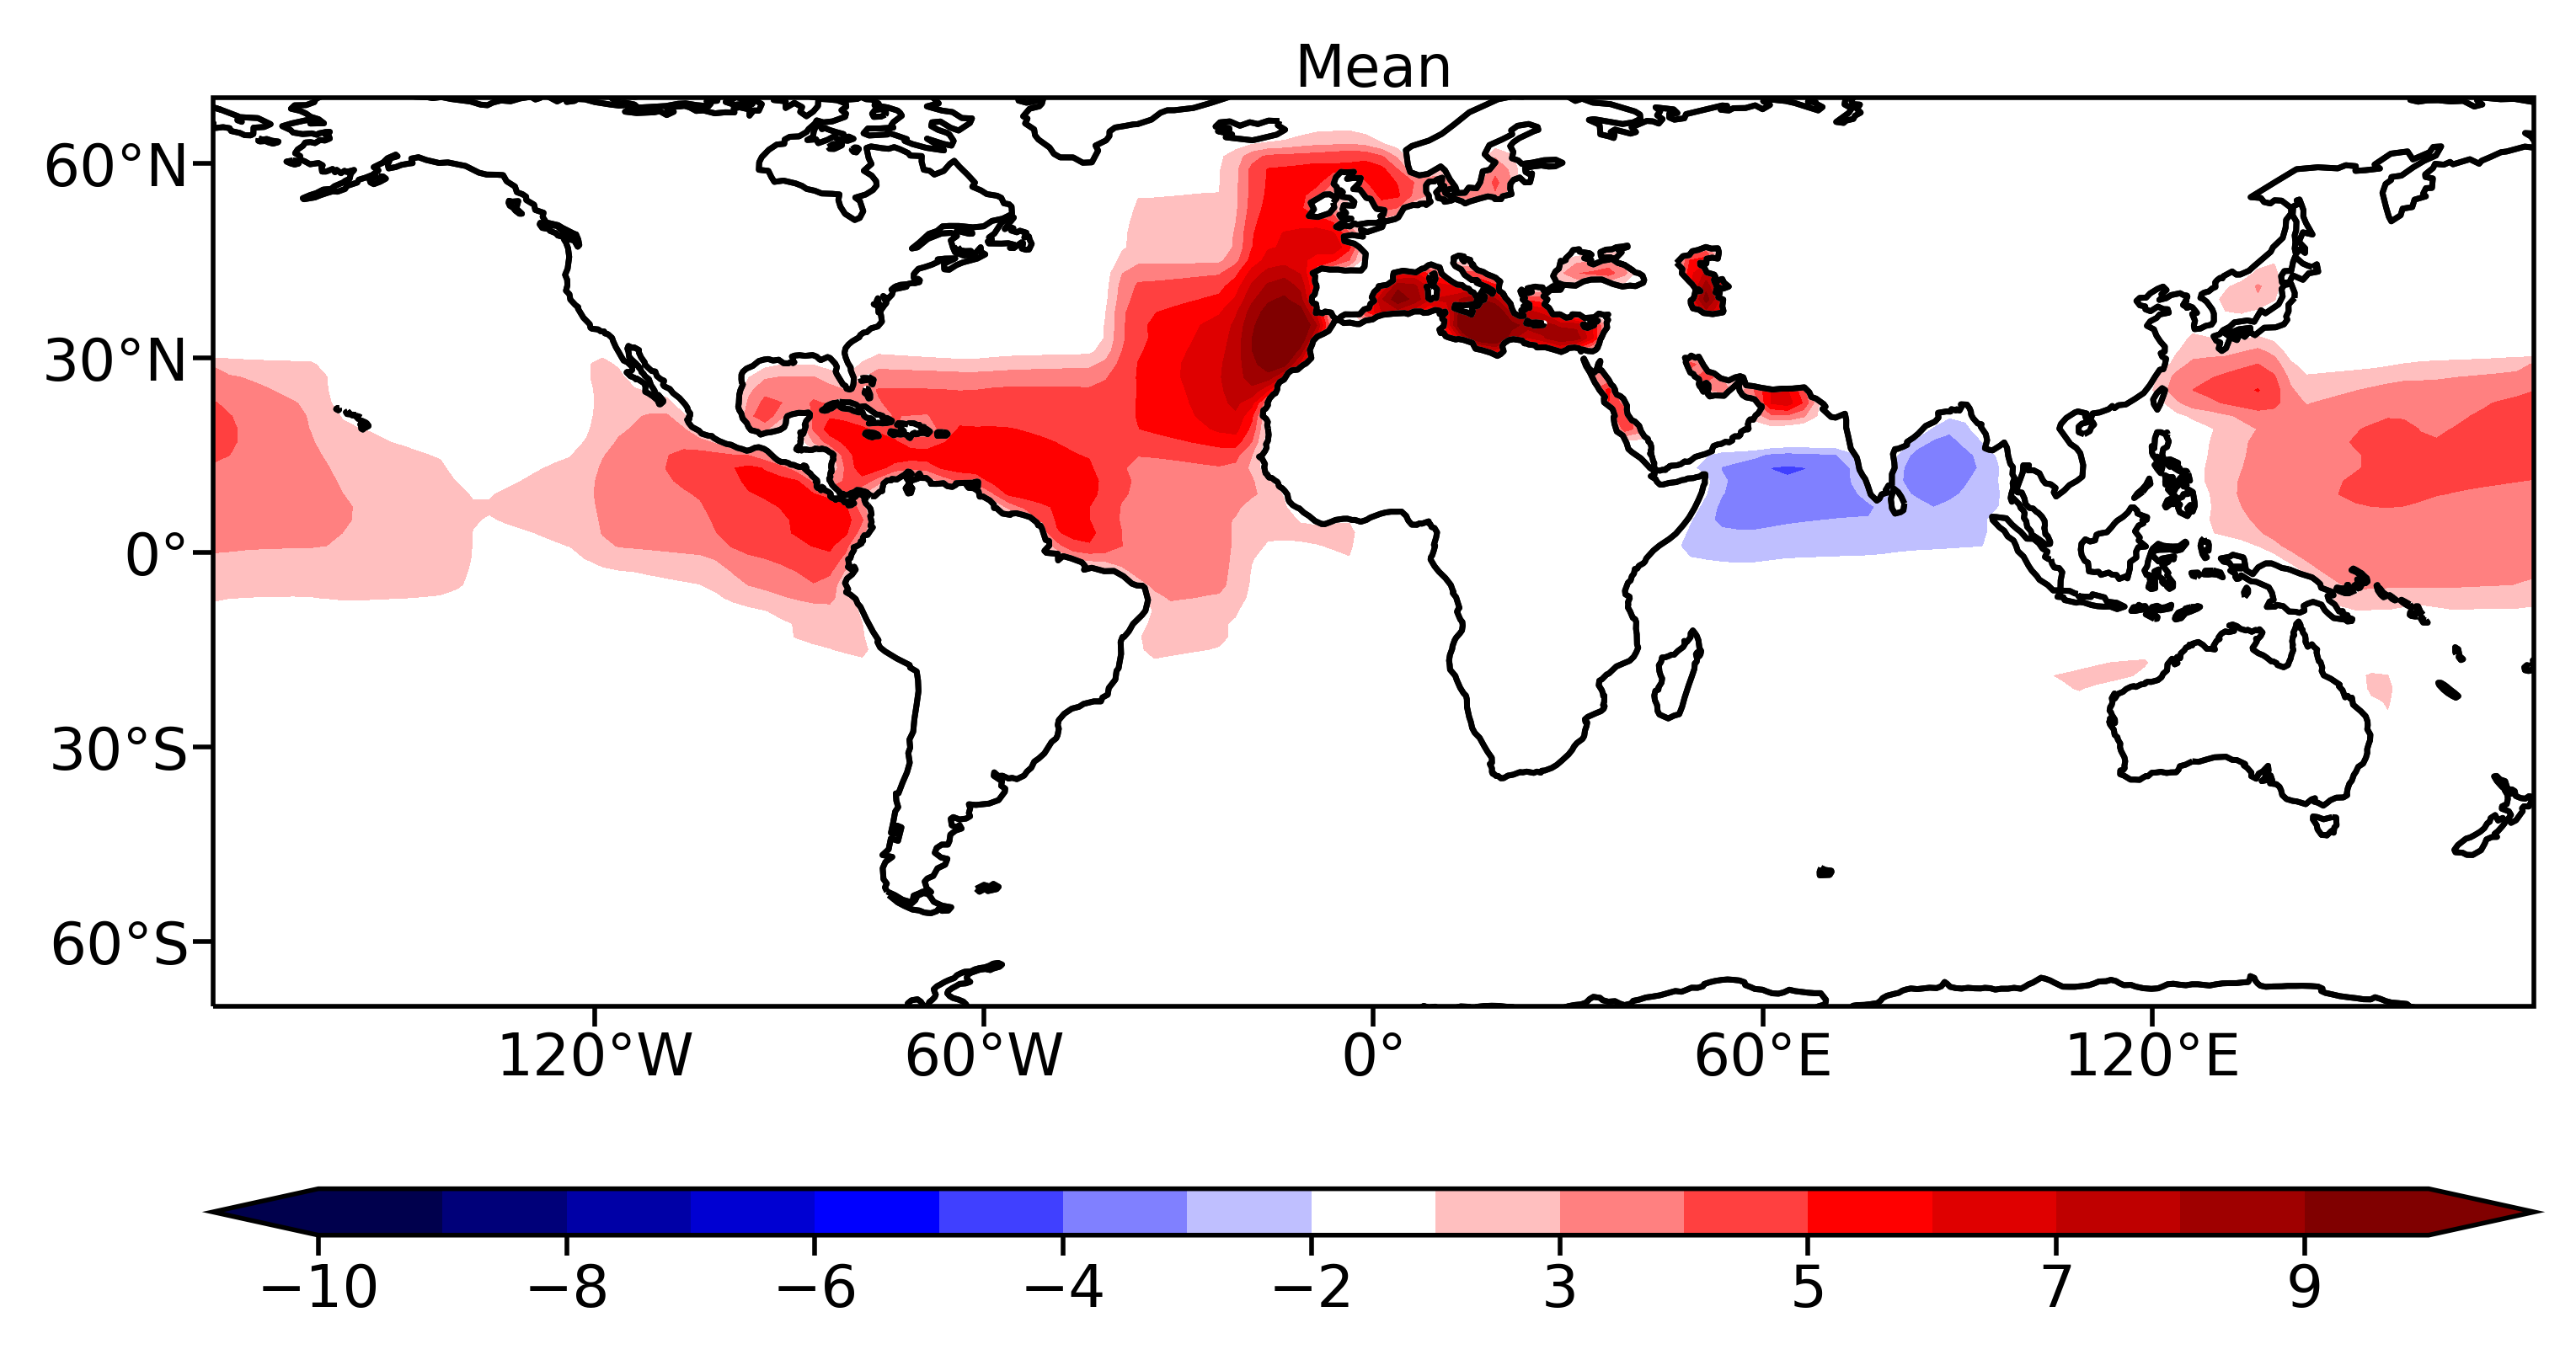

In [10]:
def plot_background(ax,var,intervals):
    lonW = -178.8
    lonE = 178.8
    latS = -70
    latN = 70.0
    fontsize=10
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '110m'
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.set_xticks([-120,-60,0,60,120], crs=ccrs.PlateCarree())
    ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
    
    lats=var.lat
    lons=var.lon
    
#     bounds = np.arange(-10, 11, 1)
    bounds = np.array([-10,-9,-8,-7,-6,-5,-4,-3,-2,2,3,4,5,6,7,8,9,10])
    N = len(bounds) - 1

#     base = plt.cm.get_cmap("bwr", N)
#     colors = base(np.arange(N))
#     # 找到 [-2,2] 对应的 bin
#     for v in [-2, -1, 0, 1]:
#         i = np.where(bounds[:-1] == v)[0][0]
#         colors[i] = [1, 1, 1, 1]   # 白色

    # 1) 先做一个离散版 bwr（每个 bin 一个颜色）
    base = plt.cm.get_cmap("seismic", N)
    colors = base(np.arange(N))

    # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
    #    bin i 对应 [bounds[i], bounds[i+1]]
    i1 = np.where(bounds[:-1] == -2)[0][0]  # [-1,0]
#     i2 = np.where(bounds[:-1] ==  0)[0][0]  # [0,1]
    colors[i1] = [1, 1, 1, 1]
#     colors[i2] = [1, 1, 1, 1]
    
#     for v in [-2, -1, 0, 1]:
#         i = np.where(bounds[:-1] == v)[0][0]
#         colors[i] = [1, 1, 1, 1]   # 白色

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    CF = ax.contourf(lons,lats,var,bounds,transform=proj_data,norm=norm,
                 cmap=cmap,extend='both') #cmap=plt.get_cmap('seismic')
#     levels=np.array([5])
#     CF_line = ax.contour(lons,lats,var,levels,transform=proj_data,colors='white',linewidths=1)
#     ax.clabel(CF_line, inline=True, fontsize=10, fmt="%.1f")
    ax.add_feature(cfeature.COASTLINE.with_scale(res),color='black',linewidth=1)
    ax.add_feature(cfeature.LAND, color='white',zorder=1)
#     ax.add_patch(                                            # Med; lat:30-40; lon:0-40
#             mpatches.Rectangle(xy=[0, 30],
#                                width=40,
#                                height=10,
#                                facecolor='None',
#                                edgecolor='blue',
#                                lw=1,
#                                transform=ccrs.PlateCarree()))
#     ax.add_patch(                                            # East Atlantic; lat:25-45; lon:-25-(-5)
#             mpatches.Rectangle(xy=[-25, 25],
#                                width=20,
#                                height=20,
#                                facecolor='None',
#                                edgecolor='blue',
#                                lw=1,
#                                transform=ccrs.PlateCarree()))
#     ax.add_patch(                                            # Caribbean sea; lat:10-25; lon:-90-(-60)
#             mpatches.Rectangle(xy=[-90, 10],
#                                width=30,
#                                height=15,
#                                facecolor='None',
#                                edgecolor='blue',
#                                lw=1,
#                                transform=ccrs.PlateCarree()))
        
    ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

fig = plt.figure(figsize=(6, 5),dpi=500,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
var_smooth=mpcalc.smooth_n_point(sen2sst_1p5_30, 9, 1)
minVal = -10
maxVal = 10+1
cint = 1
intervals = np.arange(minVal, maxVal, cint) 

ax1,CF =plot_background(ax,var_smooth,intervals)
fontsize=12
pad=0.5
ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title('Mean',fontsize=10,pad=1)

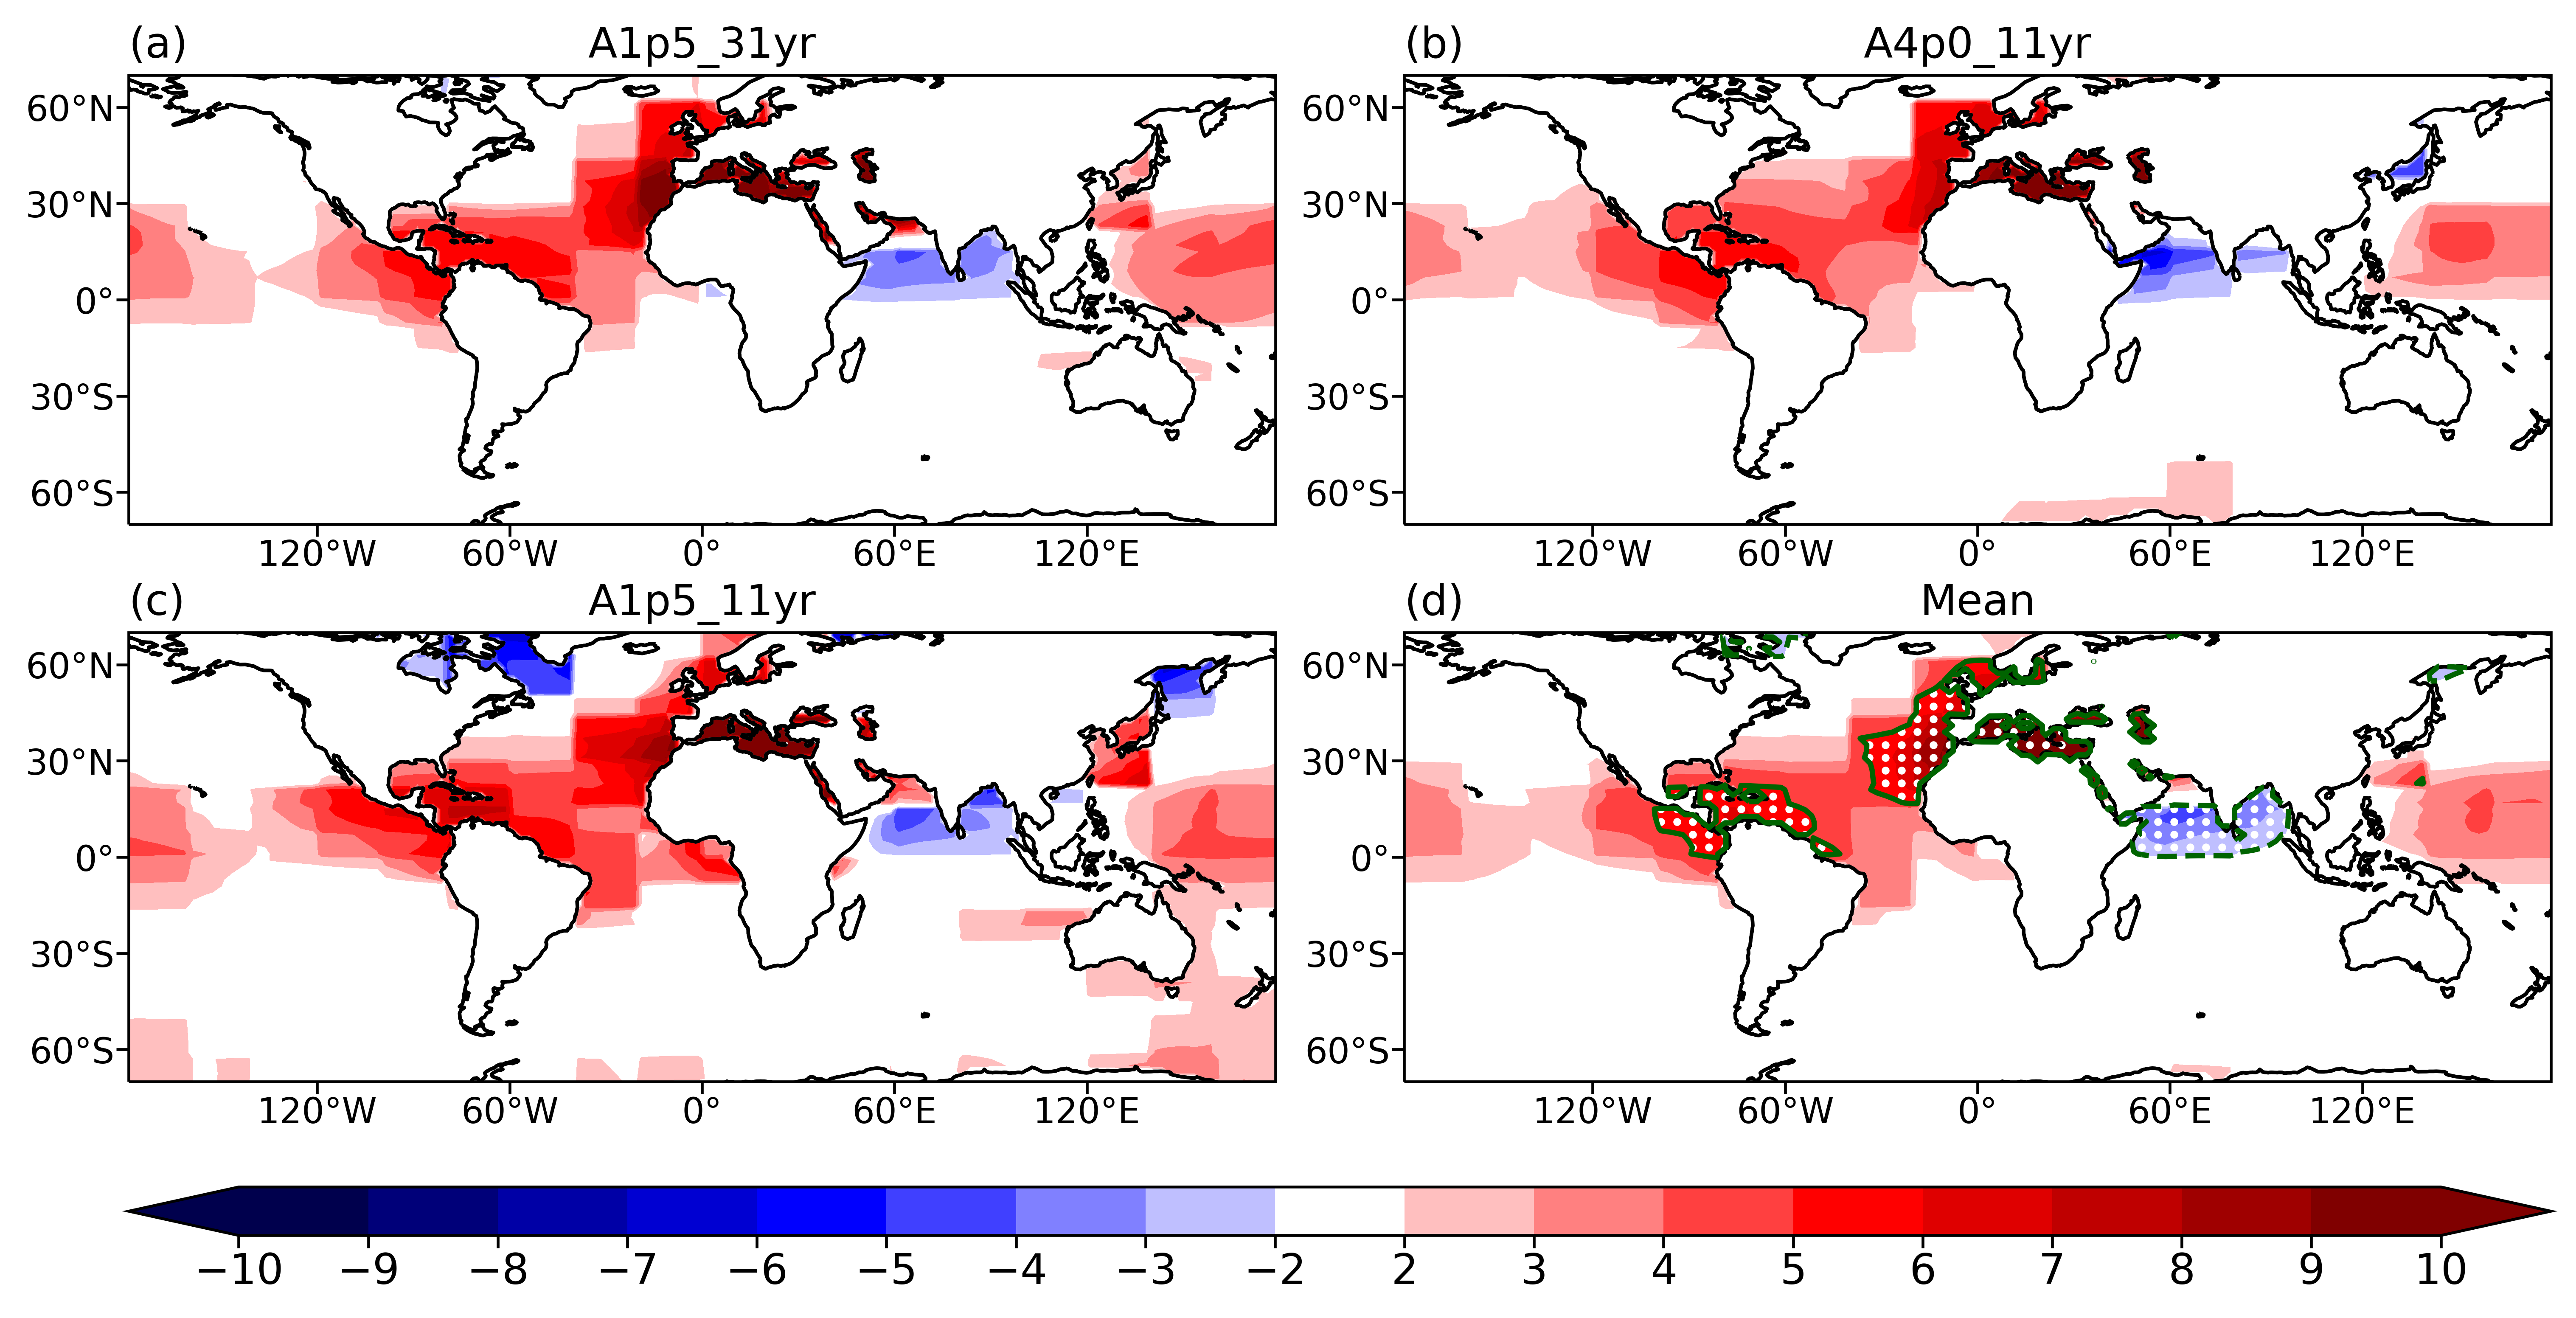

In [25]:
fig = plt.figure(figsize=(10, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=2,
                        nrows=2)
ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_1p5_30, 9, 1)
var_smooth=sen2sst_1p5_30
minVal = -10
maxVal = 10+1
cint = 1
intervals = np.arange(minVal, maxVal, cint) 

ax1,CF =plot_background(ax,var_smooth,intervals)
fontsize=12
pad=5
ax1.set_title('A1p5_31yr',fontsize=fontsize,pad=pad)
ax1.set_title('(a)',fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[0, 1],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_4p5, 9, 1)
var_smooth=sen2sst_4p5
ax2,CF =plot_background(ax,var_smooth,intervals)
ax2.set_title('A4p0_11yr',fontsize=fontsize,pad=pad)
ax2.set_title('(b)',fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[1, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_1p5_10, 9, 1)
var_smooth=sen2sst_1p5_10
ax3,CF =plot_background(ax,var_smooth,intervals)
ax3.set_title('A1p5_11yr',fontsize=fontsize,pad=pad)
ax3.set_title('(c)',fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[1, 1],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
var_smooth=sen2sst_mean
levels=np.array([-2,5])
ax4,CF =plot_background_line(ax,var_smooth,intervals,levels)
ax4.set_title('Mean',fontsize=fontsize,pad=pad)
ax4.set_title('(d)',fontsize=fontsize,pad=pad,loc='left')

cbar=plt.colorbar(CF,ax=[ax1,ax2,ax3,ax4],orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=12,pad=1)

bounds = np.array([-10,-9,-8,-7,-6,-5,-4,-3,-2,2,3,4,5,6,7,8,9,10])
cbar.set_ticks(bounds)